In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv('KNNAlgorithmDataset.csv')
X = df.drop(columns=['id', 'diagnosis']).dropna(axis=1, how='all')
y = df['diagnosis']  # M = Malignant, B = Benign

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [5]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
y_pred = knn.predict(X_test_s)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9474

Classification Report:
              precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [6]:
# ── Data for plots ────────────────────────────────────────────
# K accuracy curve
k_vals = range(1, 21)
k_accs = [accuracy_score(y_test, KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train).predict(X_test_s))
          for k in k_vals]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['B', 'M'])

# PCA 2D projection
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(scaler.transform(X))

# Top 10 features by variance
feat_var = np.var(X_train_s, axis=0)
top_idx  = np.argsort(feat_var)[::-1][:10]
top_names = [X.columns[i] for i in top_idx]
top_vals  = feat_var[top_idx]


Plot saved as knn_visualization.png


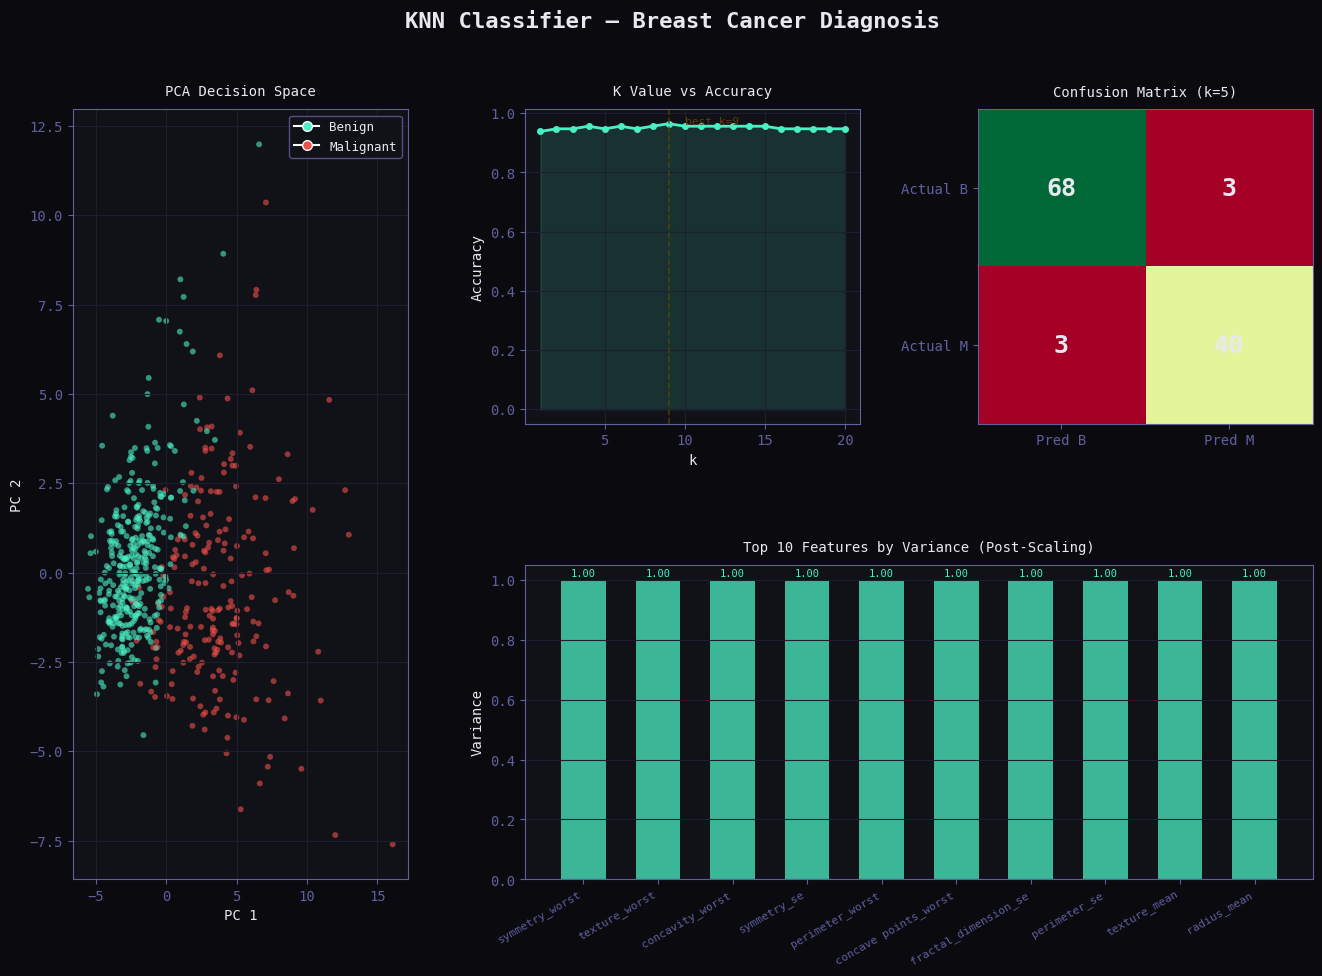

In [9]:
BG    = '#0a0a0f'
SURF  = '#111118'
TEAL  = '#4af0c4'
RED   = '#f0504a'
BROWN  = "#544207"
MUTED = '#6060a0'
TEXT  = '#e8e8f0'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   SURF,
    'axes.edgecolor':   MUTED,
    'axes.labelcolor':  TEXT,
    'xtick.color':      MUTED,
    'ytick.color':      MUTED,
    'text.color':       TEXT,
    'grid.color':       '#1e1e2e',
    'grid.linewidth':   0.8,
    'font.family':      'monospace',
})

fig = plt.figure(figsize=(16, 10), facecolor=BG)
fig.suptitle('KNN Classifier — Breast Cancer Diagnosis', fontsize=16,
             fontweight='bold', color=TEXT, y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax_pca  = fig.add_subplot(gs[:, 0])   # PCA scatter (tall, left)
ax_k    = fig.add_subplot(gs[0, 1])   # K curve
ax_cm   = fig.add_subplot(gs[0, 2])   # Confusion matrix
ax_feat = fig.add_subplot(gs[1, 1:])  # Feature bars (wide, bottom right)

# ── 1. PCA Scatter ────────────────────────────────────────────
colors = [TEAL if label == 'B' else RED for label in y]
ax_pca.scatter(X_all_pca[:, 0], X_all_pca[:, 1],
               c=colors, alpha=0.6, s=18, linewidths=0)
ax_pca.set_title('PCA Decision Space', color=TEXT, fontsize=10, pad=10)
ax_pca.set_xlabel('PC 1'); ax_pca.set_ylabel('PC 2')
ax_pca.grid(True)
from matplotlib.lines import Line2D
ax_pca.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor=TEAL, markersize=7, label='Benign'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=RED,  markersize=7, label='Malignant'),
], facecolor=SURF, edgecolor=MUTED, labelcolor=TEXT, fontsize=9)

# ── 2. K vs Accuracy ─────────────────────────────────────────
ax_k.plot(list(k_vals), k_accs, color=TEAL, linewidth=2, marker='o', markersize=4)
ax_k.fill_between(list(k_vals), k_accs, alpha=0.15, color=TEAL)
best_k = k_accs.index(max(k_accs)) + 1
ax_k.axvline(best_k, color=BROWN, linestyle='--', linewidth=1.2, alpha=0.8)
ax_k.annotate(f'best k={best_k}', xy=(best_k, max(k_accs)),
              xytext=(best_k + 1, max(k_accs) - 0.002),
              color=BROWN, fontsize=8)
ax_k.set_title('K Value vs Accuracy', color=TEXT, fontsize=10, pad=10)
ax_k.set_xlabel('k'); ax_k.set_ylabel('Accuracy')
ax_k.grid(True)

# ── 3. Confusion Matrix ───────────────────────────────────────
ax_cm.imshow(cm, cmap='RdYlGn', aspect='auto')
for i in range(2):
    for j in range(2):
        ax_cm.text(j, i, str(cm[i, j]), ha='center', va='center',
                   fontsize=18, fontweight='bold', color=TEXT)
ax_cm.set_xticks([0, 1]); ax_cm.set_yticks([0, 1])
ax_cm.set_xticklabels(['Pred B', 'Pred M'])
ax_cm.set_yticklabels(['Actual B', 'Actual M'])
ax_cm.set_title('Confusion Matrix (k=5)', color=TEXT, fontsize=10, pad=10)

# ── 4. Feature Variance Bars ──────────────────────────────────
bars = ax_feat.bar(range(len(top_names)), top_vals, color=TEAL, alpha=0.75, width=0.6)
ax_feat.set_xticks(range(len(top_names)))
ax_feat.set_xticklabels(top_names, rotation=30, ha='right', fontsize=8)
ax_feat.set_title('Top 10 Features by Variance (Post-Scaling)', color=TEXT, fontsize=10, pad=10)
ax_feat.set_ylabel('Variance')
ax_feat.grid(True, axis='y')
for bar, val in zip(bars, top_vals):
    ax_feat.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, color=TEAL)

plt.savefig('knn_visualization.png', dpi=150, bbox_inches='tight', facecolor=BG)
print("\nPlot saved as knn_visualization.png")
plt.show()